# 心理健康公开数据集可用性审计

## TL;DR

- **PSYCHE-D** 是当前唯一适合作为 P0 主训练与量表监督内部验证的数据：10,866 个完整窗口、4,036 名参与者；必须按参与者分组，标签月传感器只可表述为 PHQ-9 前 8–14 天的近两周状态筛查。
- **RESILIENT** 的 73 名参与者都没有量表前 7/14/28 天四模态窗口，不能做严格 past-only 外测；先做一次冻结模型的老人域反向时间敏感性测试，之后才可解锁全部样本做内部适配。
- **NHANES** 的官方流程是先完成 DPQ/PHQ-9、后佩戴 PAM；只能用于量表后活动/睡眠关联、辅助表征和跨周期稳健性，不能证明前置筛查。
- 真正的老人域 past-only 外部验证，需要自采“先连续采集 7–14 天设备数据，再完成 PHQ-9/GDS”的前瞻小队列。

## 方法与数据边界

本 notebook 只读取审计脚本生成的聚合结果，不读取或展示参与者级数据。源数据由 `scripts/audit/audit_mental_health_datasets.py` 只读检查，并生成 SHA-256 清单、标签/重复测量统计、时序审计和冻结版特征映射。公开文件没有原始时间戳时，结论区分为“本地逐行可验证”和“官方采集协议可确认”。

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

REPORT_DIR = Path.cwd()
summary = json.loads((REPORT_DIR / 'audit_summary.json').read_text(encoding='utf-8'))
decisions = pd.read_csv(REPORT_DIR / 'dataset_role_decisions.csv')
assert summary['validation']['passed'] is True
summary['audit_version'], summary['audit_date']

('mental-health-dataset-audit-v1', '2026-07-25')

In [2]:
headline = pd.DataFrame([
    {
        '数据集': 'PSYCHE-D',
        '参与者/完整标签': f"{summary['psyche_d']['participants_with_complete_labels']:,}人 / {summary['psyche_d']['complete_label_windows']:,}窗",
        '关键时序': 'wearable 在 end PHQ 前 8–14 天（设计级）',
        '冻结角色': '主训练 + grouped internal test',
    },
    {
        '数据集': 'RESILIENT',
        '参与者/完整标签': f"{summary['resilient']['participants']}人 / PHQ≥10: {summary['resilient']['phq_ge10']}人",
        '关键时序': '传感器同日或晚于基线量表',
        '冻结角色': '老人域反向时间敏感性；随后内部适配',
    },
    {
        '数据集': 'NHANES',
        '参与者/完整标签': f"PAM日级 {summary['nhanes']['day_unique_participants']:,}人",
        '关键时序': 'DPQ 先，PAM 后约 7 天',
        '冻结角色': 'post-assessment association',
    },
])
headline

,数据集,参与者/完整标签,关键时序,冻结角色
0,PSYCHE-D,"4,036人 / 10,866窗",wearable 在 end PHQ 前 8–14 天（设计级）,主训练 + grouped internal test
1,RESILIENT,73人 / PHQ≥10: 10人,传感器同日或晚于基线量表,老人域反向时间敏感性；随后内部适配
2,NHANES,"PAM日级 14,264人",DPQ 先，PAM 后约 7 天,post-assessment association


## PSYCHE-D：主数据与参与者级划分

完整四标签窗口为 10,866 个，来自 4,036 人；其中 end PHQ-9≥10 有 3,444 窗、1,790 人。多数人有重复季度窗口，所以随机按行切分会泄漏。冻结契约是：约 800 人保留为 untouched internal test，其余参与者用 `StratifiedGroupKFold`；插补、筛列、缩放、特征选择和校准都只能在训练折拟合。

,phq_category,start_windows,end_windows
0,0,4024,4202
1,1,3267,3220
2,2,1980,1941
3,3,1054,981
4,4,541,522


,complete_windows_per_participant,participants,participant_share
0,1,929,0.230178
1,2,774,0.191774
2,3,943,0.233647
3,4,1390,0.344400


,nominal_month_gap,adjacent_window_pairs,pair_share
0,3,6471,0.947438
1,6,293,0.042899
2,9,66,0.009663


C:\Users\Administrator\AppData\Local\Temp\ipykernel_27500\1621542360.py:10: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_27500\1621542360.py:10: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_27500\1621542360.py:10: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_27500\1621542360.py:10: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_27500\1621542360.py:10: UserWarning: Glyph 23436 (\N{CJK UNIFIED IDEOGRAPH-5B8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_27

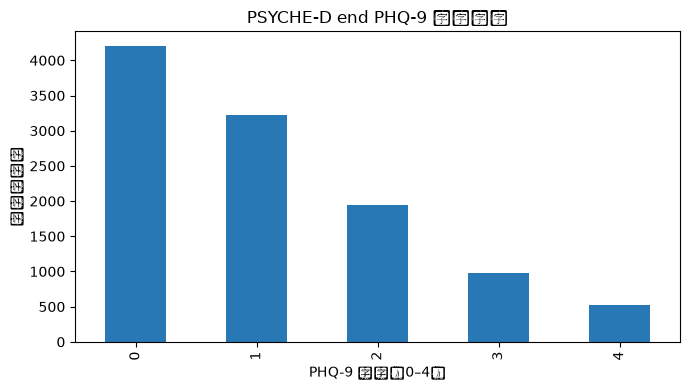

In [3]:
category = pd.read_csv(REPORT_DIR / 'psyche_category_distribution.csv')
repeat = pd.read_csv(REPORT_DIR / 'psyche_repeat_windows.csv')
intervals = pd.read_csv(REPORT_DIR / 'psyche_interval_distribution.csv')
display(category, repeat, intervals)

ax = category.plot.bar(x='phq_category', y='end_windows', legend=False, color='#2878B5', figsize=(7, 4))
ax.set_title('PSYCHE-D end PHQ-9 类别分布')
ax.set_xlabel('PHQ-9 类别（0–4）')
ax.set_ylabel('完整窗口数')
plt.tight_layout()
plt.show()

冻结的 `psyche_sensor_semantic_v1` 只纳入字段字典有明确描述的 27 个 Sleep/Steps Statistics 字段。84 个定义缺失的线性回归字段进入隔离区；动态生活方式/治疗字段因同月先后不明且与部署模态不一致，P0 排除。映射基于字段语义冻结，不基于传感器—标签性能筛选。

In [4]:
mapping = pd.read_csv(REPORT_DIR / 'psyche_feature_mapping_v1.csv')
mapping.groupby('role', dropna=False).size().rename('features').sort_values(ascending=False).to_frame()

,features
role,
quarantine_undefined_derived,84
static_ablation_only,29
sensor_v1,27
exclude_temporally_ambiguous,10
baseline_label_optional,2
target_only,2


## RESILIENT：不切小测试集，先冻结测试再适配

73 人中 PHQ-9≥10 只有 10 人。若固定 20% 测试集，约 15 人中期望仅约 2 个阳性，指标不稳定。更关键的是，四模态最晚启动时间相对 PHQ 日期为：同日 28 人、次日 37 人、其余延迟 2–20 天，另有 1 人模态缺失；量表前 7/14/28 天严格窗口均为 0。

因此先在全部 73 人上进行一次不调参的老人域跨队列、反向时间敏感性测试。保存结果后，才可用全体样本做带强正则的嵌套交叉验证适配，并明确改名为“RESILIENT 内部适配验证”。

In [5]:
res_phq = pd.read_csv(REPORT_DIR / 'resilient_phq_distribution.csv')
res_offsets = pd.read_csv(REPORT_DIR / 'resilient_sensor_start_offsets.csv')
display(res_phq, res_offsets)

,phq_score_band,participants,participant_share
0,0-4,37,0.506849
1,5-9,26,0.356164
2,10-14,5,0.068493
3,15-19,4,0.054795
4,20-27,1,0.013699


,all_modality_start_offset_days,participants,timing_interpretation
0,0.0,28,same calendar date
1,1.0,37,after PHQ date
2,2.0,3,after PHQ date
3,5.0,1,after PHQ date
4,9.0,1,after PHQ date
5,10.0,1,after PHQ date
6,20.0,1,after PHQ date
7,NaN,1,missing modality


RESILIENT 仍有真正纵向、但属于 P2 的认知探索：48 人有 ACE-III 基线—约 6 月随访配对，可研究“基线后固定早期传感器窗口 → 随访 ACE-III/变化量”。样本只适合 Ridge/ElasticNet 等简单模型与探索性结论。

## NHANES：DPQ 在前，PAM 在后

本地 `DPQ_G/H.xpt` 只有 `SEQN` 与问卷字段，没有日期或时间；日级 CSV 的 `calendar_date` 全部重置到 2000-01-02 至 2000-01-15，不能逐人对时。CDC 官方流程则明确 DPQ 在 MEC 私密访谈中完成，PAM 在 MEC 检查会话结束时开始，并在离开 MEC 后佩戴约 7 天。因此研究角色必须是 `post-assessment/post-outcome association`。

In [6]:
nhanes_timing = pd.read_csv(REPORT_DIR / 'nhanes_protocol_timing.csv')
nhanes_schema = pd.read_csv(REPORT_DIR / 'nhanes_local_schema_audit.csv')
display(nhanes_timing, nhanes_schema)

,stage,event,location,relative_timing,interpretation
0,1,DPQ/PHQ-9,MEC 私密访谈,先,回顾访谈前两周症状
1,2,PAM 启动,MEC 检查会话结束,后,设备在离开 MEC 后开始/继续记录
2,3,PAM 佩戴,离开 MEC 后,随后约 7 天,属于量表评估后的活动/睡眠窗口


,file,rows,columns,date_or_time_columns
0,DPQ_G.xpt,5615,11,(none)
1,DEMO_G.xpt,9756,48,(none; RIDEXMON is season only)
2,DPQ_H.xpt,5924,11,(none)
3,DEMO_H.xpt,10175,47,(none; RIDEXMON is season only)
4,NHANES Preliminary Day Level Output.csv,89104,42,calendar_date and derived sleep timestamps; ca...


## 决策与下一步

1. 立即冻结 PSYCHE-D 的参与者级测试名单、三个任务（state/forecast_1m/forecast_2m）、标签定义和 27 个 P0 传感器字段。
2. 训练 V2-reduced、Logistic/ElasticNet、LightGBM 三类基线；分别报告 sensor-only、start-only、start+sensor，使用参与者 cluster bootstrap 置信区间。
3. RESILIENT 先 one-shot 冻结迁移测试，后做全体嵌套 CV 适配；不再宣称严格外部筛查验证。
4. NHANES 只做量表后关联/辅助表征，成绩与 PSYCHE-D past-only 主任务完全分开。
5. 启动自采老人前瞻验证：先采 7–14 天设备数据，再做 PHQ-9/GDS；这是解决目标年龄与时间方向缺口的唯一直接证据。

In [7]:
decisions

,dataset,primary_role,time_direction,can_train_primary_model,can_be_strict_past_only_external_test,p0_action
0,PSYCHE-D,主训练 + 参与者级内部验证,传感器在 end PHQ-9 前 8–14 天（设计级确认）,是,否（主训练来源）,冻结约 800 人内部测试；其余做 grouped CV
1,RESILIENT,老人域一次性迁移敏感性测试；之后内部适配,传感器同日或晚于基线量表,否（73 人、PHQ>=10 仅 10 人）,否,全部 73 人先 one-shot；解锁后全体嵌套 CV，不切固定小测试集
2,NHANES,量表后活动/睡眠关联与辅助表征,DPQ 先，PAM 后约 7 天,仅可作辅助关联/预训练,否,与 PSYCHE-D 主成绩分开报告，禁止前置筛查表述
3,项目自采前瞻队列,真正老人域 past-only 外部验证,先采 7–14 天设备数据，再做 PHQ-9/GDS,后续可用于校准,是（冻结模型后）,现在冻结方案并启动采集；量表前窗口不得回填
